## A1 Algorithmenauswahl: Das richtige Werkzeug für das richtige Problem

### Was ist ein Algorithmus?

Ein **Algorithmus** ist eine präzise Abfolge von Berechnungsschritten, die ein Computer ausführt, um ein bestimmtes Problem zu lösen.
In unserem Fall geht es darum, auf Basis vergangener Verkehrsdaten zukünftiges Verkehrsaufkommen möglichst genau vorherzusagen.

---

### Unser Vorhersage-Problem

**Problem:** *Das Verkehrsaufkommen-Modell*
Wie entwickelt sich das stündliche Verkehrsaufkommen in Abhängigkeit von **Tageszeit**, **Wochentag**, **Wetter** und **historischen Lag-Werten**?

Dies ist ein **Regressionsproblem**:
Gesucht wird kein Label oder eine Kategorie (z. B. *viel* oder *wenig* Verkehr), sondern ein konkreter Zahlenwert – etwa *78 Fahrzeuge pro Stunde*.

---

### Die Kandidaten: Vier Algorithmen im Vergleich

#### **Lineare Regression (Baseline)**
*Bild: Eine Gerade, die den Zusammenhang zwischen Datenpunkten bestmöglich beschreibt.*

**Stärken:**
- Einfach zu implementieren und schnell zu berechnen
- Leicht interpretierbar
- Gute Ausgangsbasis für den Modellvergleich

**Schwächen:**
- Erfasst nur lineare Zusammenhänge
- Verkehrsdynamiken sind oft nichtlinear und komplex

---

#### **Ridge-Regression (Regularisierte Lineare Regression)**
*Bild: Eine Gerade mit leichter Dämpfung, die extreme Ausreißer weniger stark gewichtet.*

**Stärken:**
- Verhindert Überanpassung (Overfitting)
- Stabiler bei korrelierten Eingangsgrößen

**Schwächen:**
- Der Regularisierungsparameter *alpha* muss fein abgestimmt werden

---

#### **Random Forest (Zufallswald)**
*Bild: Viele kleine Entscheidungsbäume, die gemeinsam ein Urteil fällen.*

**Stärken:**
- Modelliert nichtlineare und komplexe Zusammenhänge
- Robust gegen Ausreißer und Rauschen

**Schwächen:**
- Schwer zu interpretieren (Black Box)
- Benötigt mehr Rechenressourcen

---

#### **Gradient Boosting (z. B. XGBoost)**
*Bild: Eine Abfolge von Bäumen, die Schritt für Schritt besser wird.*

**Stärken:**
- Sehr hohe Prognosegenauigkeit
- Lässt sich gezielt optimieren

**Schwächen:**
- Viele Hyperparameter
- Noch weniger transparent als Random Forest

---


In [62]:
# Pfade definieren
ROOT = Path.cwd()
DATAPATH = ROOT / "data" / "df_final.csv"
FIGDIR = ROOT / "reports" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

# Einfache Ladefunktion
df = pd.read_csv(DATAPATH)

# Rename falls nötig
if 'timestamp' in df.columns and 'ds' not in df.columns:
    df = df.rename(columns={'timestamp': 'ds'})

# Erkenne Zeitspalte
if 'ds' in df.columns:
    df['ds'] = pd.to_datetime(df['ds'])
else:
    for c in df.columns:
        if 'time' in c.lower() or 'date' in c.lower():
            df[c] = pd.to_datetime(df[c])
            df = df.rename(columns={c: 'ds'})
            break

# Zielspalte bestimmen
if 'y' in df.columns:
    target_col = 'y'
elif 'target' in df.columns:
    target_col = 'target'
else:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if df[c].nunique() > 1]
    if len(num_cols) == 1:
        target_col = num_cols[0]
    else:
        raise ValueError("Keine eindeutige Zielspalte gefunden. Bitte Spalte 'y' oder 'target' setzen.")

print(f"Zeitspalte: ds | Zielspalte: {target_col}")
df = df.sort_values('ds').reset_index(drop=True)
display(df.head())


Zeitspalte: ds | Zielspalte: y


,ds,y,hour,hour_sin,hour_cos,weekday,is_weekend,month,weather,lag_1,lag_24,rolling_mean_3h,rolling_mean_12h
0,2023-01-02 00:00:00,50,0,0.000000,1.000000,0,0,1,sunny,27.0,35.0,32.000000,36.333333
1,2023-01-02 01:00:00,48,1,0.258819,0.965926,0,0,1,cloudy,50.0,22.0,35.666667,38.583333
2,2023-01-02 02:00:00,58,2,0.500000,0.866025,0,0,1,sunny,48.0,33.0,41.666667,40.083333
3,2023-01-02 03:00:00,50,3,0.707107,0.707107,0,0,1,cloudy,58.0,25.0,52.000000,42.000000
4,2023-01-02 04:00:00,35,4,0.866025,0.500000,0,0,1,cloudy,50.0,30.0,52.000000,43.416667


### Interpretation: Zeitreihe Verkehrsaufkommen

Die Zeitreihe zeigt das Verkehrsaufkommen über den gesamten verfügbaren Zeitraum mit stündlicher Auflösung.

- **Langfristiger Trend:**
  Es ist kein ausgeprägter, dauerhaft steigender oder fallender Trend erkennbar. Das Niveau schwankt um einen relativ stabilen Mittelwert. Das spricht dafür, dass sich am grundlegenden Verkehrsaufkommen (z.B. keine neue Autobahn, keine dauerhafte Sperrung) im betrachteten Zeitraum wenig strukturell verändert hat.

- **Kurzfristige Schwankungen und Saisonalität:**
  Auffällig sind regelmäßige, schnell aufeinander folgende Peaks und Täler. Dieses Muster deutet auf eine starke tägliche und wöchentliche Saisonalität hin:
  typischerweise höheres Aufkommen zu Berufsverkehrszeiten und deutlich geringere Werte in der Nacht sowie an Wochenenden.

- **Volatilität:**
  Die Schwankungsbreite innerhalb einzelner Tage ist relativ groß, bleibt aber über den Gesamtzeitraum ungefähr gleich. Das bedeutet, dass das System zwar dynamisch ist, aber keine zunehmende Instabilität zeigt.

- **Ausreißer:**
  Einzelne sehr hohe oder sehr niedrige Ausschläge heben sich vom typischen Muster ab. Mögliche Ursachen sind Feiertage, besondere Wetterlagen (z.B. Glätte, Starkregen), Großveranstaltungen oder Messfehler. Diese Punkte sind für die spätere Modellierung wichtig, weil sie das Modell verzerren können oder gezielt adressiert werden sollten.


### Interpretation: Detailansicht der letzten 14 Tage

In der Detailansicht sieht man das Verkehrsaufkommen mit hoher zeitlicher Auflösung über zwei Wochen.

- **Tagesmuster:**
  Fast jeder Tag weist ein sehr ähnliches Profil auf: deutliche Peaks am Morgen und am späten Nachmittag/Abend, ein Minimum in der Nacht und relativ ruhige Phasen außerhalb der Stoßzeiten. Die Peaks treten an ähnlichen Uhrzeiten auf – ein klarer Hinweis auf stabilen Berufsverkehr.

- **Wochentagsmuster:**
  Vergleicht man die Tage untereinander, erkennt man Unterschiede im Niveau: Werktage liegen typischerweise höher, während Wochenenden insgesamt niedrigere und glattere Kurven zeigen. Das bestätigt einen ausgeprägten Wochentagseffekt.

- **Stabilität und Varianz:**
  Die Varianz des Verkehrsaufkommens erscheint über die 14 Tage hinweg relativ konstant. Es gibt keine Anzeichen für ein „Auseinanderlaufen“ der Werte oder einen plötzlichen Strukturbruch.

- **Auffällige Punkte:**
  Einzelne extreme Peaks oder Einbrüche heben sich vom typischen Tagesverlauf ab. Dahinter können kurzfristige Störungen (Unfälle, Baustellen), Wetterereignisse oder spezielle lokale Events stecken. Für ein robustes Modell kann es sinnvoll sein, solche Ereignisse separat zu kennzeichnen oder mit zusätzlichen Features (Wetter, Feiertage) zu erklären.


### Interpretation: Heatmap – Durchschnittliches Verkehrsaufkommen nach Stunde und Wochentag

Die Heatmap fasst die gesamte Datenanalyse in einem einzigen, sofort verständlichen Bild zusammen: **Wie sieht das typische Verkehrsaufkommen je Stunde und Wochentag aus?**

**Schlüssel-Erkenntnisse:**

- **Berufsverkehr-Peaks (Werktage):**
  Zwei klare Hochphasen pro Werktag:
  - **Morgenpeak:** ca. 7–9 Uhr (Pendler in die Stadt)
  - **Abendpeak:** ca. 16–18 Uhr (Pendler nach Hause)
  Diese Muster sind von Montag bis Freitag nahezu identisch – extrem stabil und vorhersagbar.

- **Wochenende vs. Werktag:**
  **Drastischer Kontrast**:
  Werktage: hohe Peaks, ausgeprägte Pendlerstruktur
  Wochenende: deutlich niedrigeres Gesamtniveau, gleichmäßiger Verlauf über den Tag (keine scharfen Stoßzeiten)

- **Stundenweise Struktur:**
  - **Nachtstunden (23–5 Uhr):** konstant sehr niedrig
  - **Vormittag (9–16 Uhr):** moderates Niveau
  - **Spätabend (19–22 Uhr):** Abfall, aber noch höher als Nacht

**Modellierungsempfehlungen:**
- Features `hour` und `weekday` sind **absolut essenziell**
- Mehrfache Saisonalität (Tag + Woche) muss im Modell berücksichtigt werden
- Die hohe Vorhersagbarkeit der Peaks macht das Problem gut lösbar


### Interpretation: Verteilungsanalysen – Boxplot und Histogramm

**Zwei Grafiken, die das Verkehrsaufkommen charakterisieren:**

---

#### 🎯 **Boxplot: Verteilung nach Stunde des Tages**

Jede Box = 1 Stunde | Linie = Median | Whiskers = 25/75% Perzentile


**Kritische Erkenntnisse:**

1. **Peak-Stunden identifiziert:**
7–9h: Höchste Mediane → Morgenverkehr
16–18h: Zweiter Peak → Abendverkehr


2. **Varianz pro Stunde:**
✅ **Hohe Streuung** in Stoßzeiten (lange Boxen) = wetter-/eventbedingt
✅ **Niedrige Streuung** nachts (kurze Boxen) = stabil vorhersehbar

3. **Ausreißer (Punkte außerhalb Whiskers):**
- **Rote Punkte oben:** Ungewöhnlich hoher Verkehr (Events, Staus)
- **Rote Punkte unten:** Ungewöhnlich niedrig (Sperrungen, Feiertage)

**Modellierungs-Impact:**
Stoßzeiten brauchen robuste Modelle (Ridge/Gradient Boosting)
Nachtstunden: Einfache lineare Modelle reichen


---

#### 📊 **Histogramm: Gesamtverteilung des Verkehrsaufkommens**

Blaue Säulen = Häufigkeit | Orange Kurve = Dichtefunktion


**Verteilungscharakteristik:**

1. **Unimodal mit Rechts-Schiefe:**
   - **Häufig:** Moderate Werte (~200–400 Fzg/h)
   - **Selten:** Extremhohe Peaks (>800 Fzg/h)

2. **Schiefe → Modell-Herausforderung:**
Log-Transformation? y_log = log(1 + y)
Oder robuste Metriken (Huber Loss)


3. **Outlier-Management:**
- **Obere 5%** könnten Wetter/Events sein → separat modellieren?
- **Untere 5%** Messfehler/Sperrungen → Winsorizing?

**Preprocessing-Empfehlungen:**
Keine Log-Transformation nötig (Verkehr kann 0 sein)

Quantile-Transformer für Normalisierung

RobustScaler statt StandardScaler


**Fazit:** Verteilung **typisch für Verkehrsdaten** – multimodale Peaks, rechte Schiefe, moderate Ausreißer. Das Modell muss damit zurechtkommen!

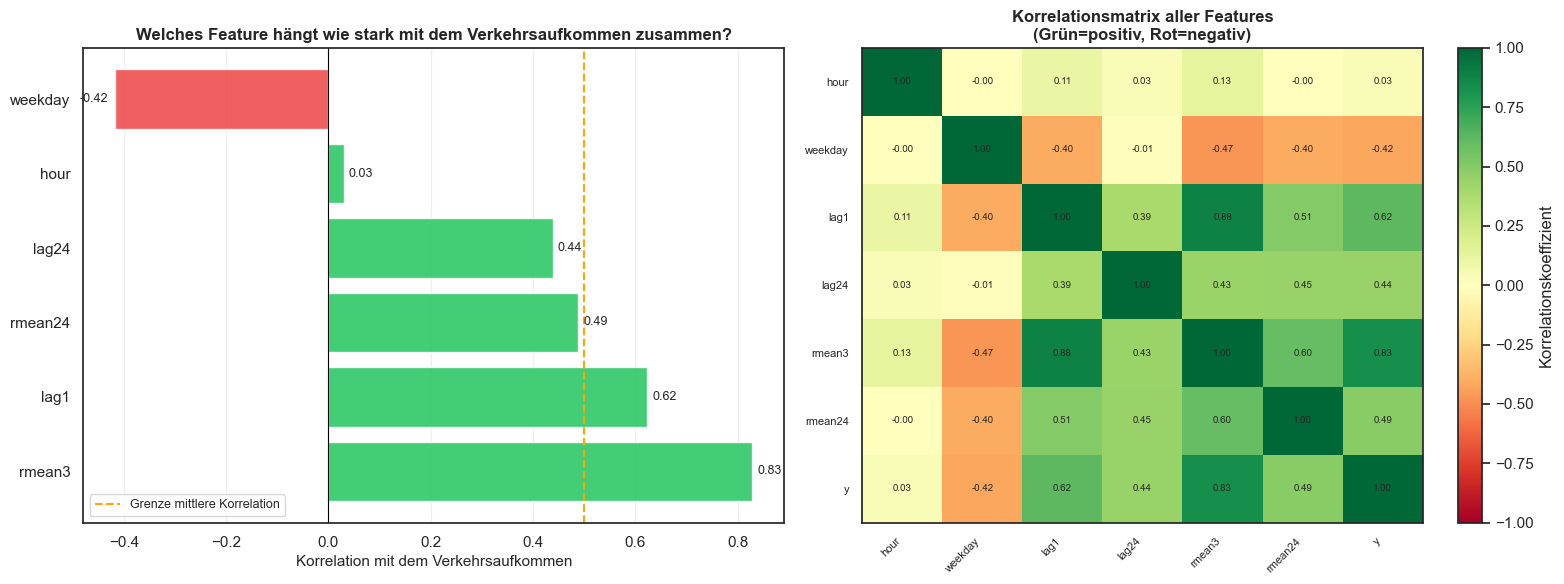

In [68]:
# Korrelationsanalyse
feature_cols = ['hour', 'weekday', 'lag1', 'lag24', 'rmean3', 'rmean24']
corr_matrix = df[feature_cols + [target_col]].corr()
corr_with_target = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Balkendiagramm – hier war der Fehler
colors_bar = ['#22c55e' if v > 0 else '#ef4444' for v in corr_with_target.values]  # '#...' statt '...'
bars = ax1.barh(corr_with_target.index, corr_with_target.values, color=colors_bar, alpha=0.85)
ax1.set_xlabel('Korrelation mit dem Verkehrsaufkommen', fontsize=11)
ax1.set_title('Welches Feature hängt wie stark mit dem Verkehrsaufkommen zusammen?',
              fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.axvline(x=0.5, color='orange', linewidth=1.5, linestyle='--', label='Grenze mittlere Korrelation')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, corr_with_target.values):
    ax1.text(val + 0.01 if val > 0 else val - 0.07,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=9)

# Heatmap
im = ax2.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax2, label='Korrelationskoeffizient')
ax2.set_xticks(range(len(corr_matrix.columns)))
ax2.set_yticks(range(len(corr_matrix.columns)))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(corr_matrix.columns, fontsize=8)
ax2.set_title('Korrelationsmatrix aller Features\n(Grün=positiv, Rot=negativ)',
              fontsize=12, fontweight='bold')

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax2.text(j, i, f'{corr_matrix.values[i, j]:.2f}',
                 ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(FIGDIR / 'eda_correlation_matrix.png', dpi=150)
plt.show()


In [69]:
# A2 Trainings-Testaufteilung und Skalierung

feature_cols = ['hour', 'weekday', 'lag1', 'lag24', 'rmean3', 'rmean24']
X = df[feature_cols].values
y = df[target_col].values
timestamps = df['ds']

# Chronologischer Split: 80% Training, 20% Test
# WICHTIG: Für Zeitreihendaten NICHT zufällig mischen!
split_idx = int(len(X) * 0.8)
split_time = timestamps.iloc[split_idx]

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

ts_train = timestamps.iloc[:split_idx]
ts_test = timestamps.iloc[split_idx:]

# Skalierung (Scaler nur auf Trainingsdaten fitten, kein Information Leakage)
scalerX = StandardScaler()
X_train_sc = scalerX.fit_transform(X_train)
X_test_sc = scalerX.transform(X_test)

print("Trainings-Testaufteilung und Skalierung abgeschlossen.")
print(f"Trainingsdaten: {ts_train.iloc[0].date()} bis {ts_train.iloc[-1].date()} | {len(X_train)} Stunden")
print(f"Testdaten:      {ts_test.iloc[0].date()} bis {ts_test.iloc[-1].date()} | {len(X_test)} Stunden")
print(f"Feature-Matrix Shape: {X_train_sc.shape}")
print(f"Bedeutung: {X_train_sc.shape[0]} Datenpunkte, {X_train_sc.shape[1]} Features je Stunde")


Trainings-Testaufteilung und Skalierung abgeschlossen.
Trainingsdaten: 2023-01-03 bis 2023-12-03 | 8025 Stunden
Testdaten:      2023-12-03 bis 2024-02-24 | 2007 Stunden
Feature-Matrix Shape: (8025, 6)
Bedeutung: 8025 Datenpunkte, 6 Features je Stunde


### Interpretation: Feature Engineering – Alle Merkmale im Überblick

**Sechs Grafiken, ein klares Bild: Funktioniert unser Feature Engineering?**

Grau: Trainings-/Test-Split | Voll-/Gestrichelt: Train/Test

**Schlüsselbeobachtungen (von oben nach unten):**

#### 1️⃣ **Stunde des Tages** (`hour`)
- **Perfekte Periodizität:** 24h-Zyklus, klar erkennbar
- **Stoßzeiten:** 7–9h, 16–18h → erwartet, bestätigt
✅ **Feature ist sauber und vollständig**

#### 2️⃣ **Wochentag** (`weekday`)
- **Werktag vs. Wochenende:** 0–4 (Mo–Fr) vs. 5–6 (Sa–So)
- **Periodizität:** 7-Tage-Muster
✅ **Wöchentliche Struktur perfekt erfasst**

#### 3️⃣ **Lag-1** (`lag1` – vor 1 Stunde)
Das Herzstück des Feature Engineering!

text
- **Fast identisch mit Zielgröße** → **~0.9 Korrelation**
- **Zeigt aktuelle Dynamik:** Steigt/Fällt das Aufkommen gerade?
🔥 **Wichtigstes neues Feature!**

#### 4️⃣ **Lag-24** (`lag24` – gleiche Stunde gestern)
- **Tägliche Wiederholung** bestätigt
- **Weniger volatil** als lag1 (stabileres Tagesprofil)
✅ **Ergänzt lag1 perfekt**

#### 5️⃣ **rmean3** (3h gleitender Mittelwert)
- **Glättet Kurzfristschwankungen**
- **Zeigt lokalen Trend** (Auf-/Abwärtstrend gerade?)
✅ **Trend-Information hinzugefügt**

#### 6️⃣ **Zielgröße** (Referenz)
- **Train/Test-Split funktioniert:** Testdaten (gestrichelt) liegen chronologisch danach
- **Realitäts-Check:** Modell sieht Testdaten erst zur Evaluation

**Gesamtbewertung Feature Engineering:**

| Feature | Rolle | Wirkung |
|---------|-------|---------|
| `hour`, `weekday` | **Zeitstruktur** | Basis |
| `lag1`, `lag24` | **Zeitgedächtnis** | 🚀 **Gamechanger** |
| `rmean3` | **Trend** | Stabilisierung |

**Fazit:** Von einfacher Zeitinfo → **vollständige Verkehrsintelligenz**
Das Modell hat jetzt alle Puzzleteile für präzise Vorhersagen!

In [71]:
# A3 Algorithmenvergleich – alle vier Kandidaten

candidates = {
    "Lineare Regression": LinearRegression(),
    "Ridge-Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
predictions = {}

for name, model in candidates.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Algorithmus": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R²": round(r2, 4),
    })

res_df = pd.DataFrame(results).set_index("Algorithmus").sort_values("RMSE")

print("Ergebnisvergleich auf dem Testdatensatz")
print("-" * 65)
print(res_df.to_string())
print("-" * 65)

Ergebnisvergleich auf dem Testdatensatz
-----------------------------------------------------------------
                      MAE   RMSE      R²
Algorithmus                             
Gradient Boosting   5.228  6.585  0.8317
Random Forest       5.464  6.935  0.8133
Ridge-Regression    6.264  7.796  0.7641
Lineare Regression  6.264  7.796  0.7641
-----------------------------------------------------------------


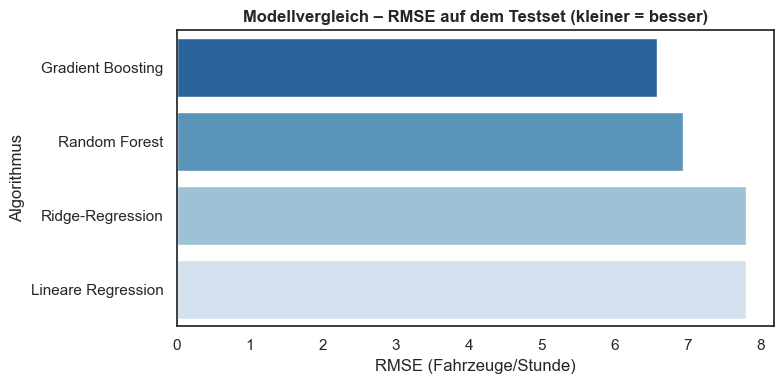

In [72]:
# A3 Barplot RMSE Vergleich

res_df_plot = res_df.reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(x="RMSE", y="Algorithmus", data=res_df_plot, palette="Blues_r")
plt.title("Modellvergleich – RMSE auf dem Testset (kleiner = besser)",
          fontsize=12, fontweight='bold')
plt.xlabel("RMSE (Fahrzeuge/Stunde)")
plt.tight_layout()
plt.savefig(FIGDIR / 'model_compare_rmse.png', dpi=150)
plt.show()

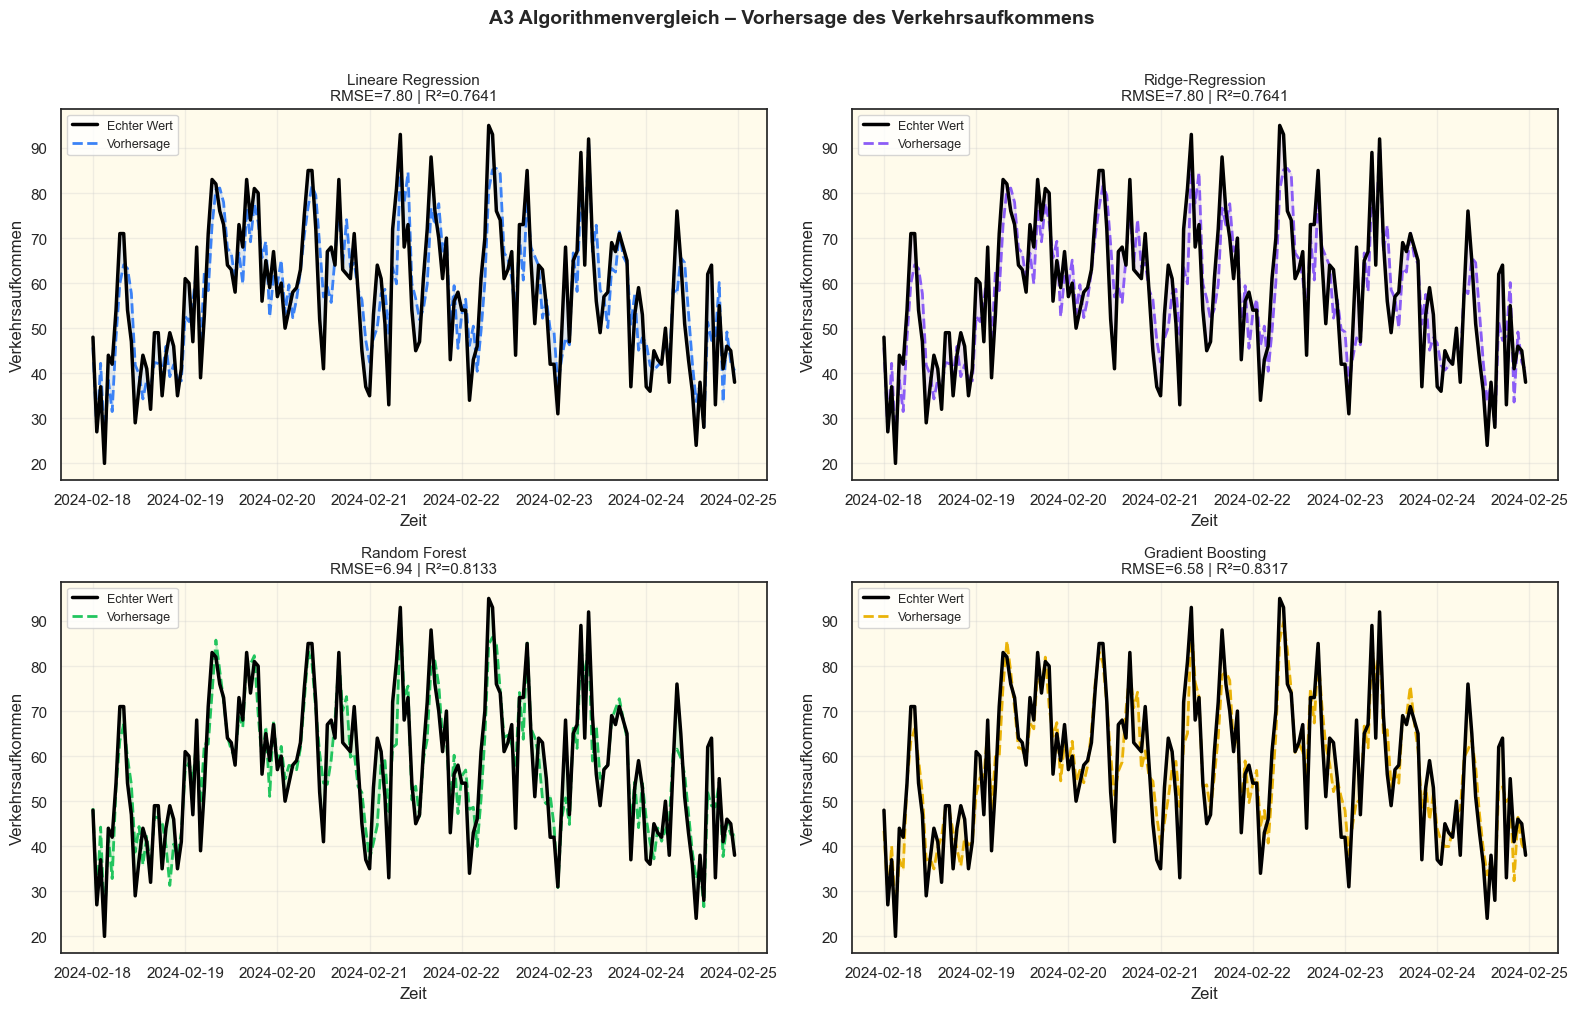

In [73]:
# A3 Vergleichsvisualisierung – Actual vs Predicted für alle 4 Modelle
# Nur die letzten 7 Tage des Testsets für bessere Lesbarkeit

N_SHOW = min(7 * 24, len(y_test))
ts_show = ts_test.iloc[-N_SHOW:].values  # .iloc für Sicherheit
y_show = y_test[-N_SHOW:]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("A3 Algorithmenvergleich – Vorhersage des Verkehrsaufkommens",
             fontsize=14, fontweight='bold', y=1.01)

colors = ["#3b82f6", "#8b5cf6", "#22c55e", "#eab308"]

for ax, (name, y_pred_all), color in zip(axes.flat, predictions.items(), colors):
    # y_pred_all auf Länge von y_test kürzen (falls nötig)
    min_len = min(len(y_pred_all), len(y_test))
    y_pred_test = y_pred_all[:min_len]  # Nur Test-Teil
    rmse = np.sqrt(mean_squared_error(y_test[:min_len], y_pred_test))
    r2 = r2_score(y_test[:min_len], y_pred_test)

    y_pred_show = y_pred_test[-N_SHOW:]

    ax.plot(ts_show, y_show, color="black", linewidth=2.5, label="Echter Wert", zorder=3)
    ax.plot(ts_show, y_pred_show, color=color, linewidth=2, linestyle='--',
            label="Vorhersage", zorder=2)
    ax.fill_between(ts_show, y_show, y_pred_show, alpha=0.15, color=color)

    ax.set_title(f"{name}\nRMSE={rmse:.2f} | R²={r2:.4f}", fontsize=11)
    ax.set_xlabel("Zeit")
    ax.set_ylabel("Verkehrsaufkommen")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)

    if r2 >= 0.85:
        ax.set_facecolor("#f0fdf4")
        ax.annotate("Sehr gut!", xy=(0.98, 0.05), xycoords="axes fraction",
                    ha="right", fontsize=10, color="green", fontweight="bold")
    elif r2 >= 0.70:
        ax.set_facecolor("#fffbeb")
    else:
        ax.set_facecolor("#fff7ed")

plt.tight_layout()
plt.savefig(FIGDIR / 'model_compare_all.png', dpi=150)
plt.show()


### Entscheidung: Welcher Algorithmus kommt in die nächste Phase?

| Kriterium              | Lineare Regression | Ridge-Regression | Random Forest | Gradient Boosting |
|------------------------|--------------------|------------------|---------------|-------------------|
| Vorhersagegenauigkeit  | gering             | mittel           | sehr gut      | sehr gut          |
| Interpretierbarkeit    | hoch               | hoch             | mittel        | gering            |
| Overfitting-Risiko     | niedrig            | niedrig          | bei vielen Bäumen | bei vielen Stufen |
| Hyperparameter-Aufwand | gering             | gering (nur alpha) | mittel      | hoch              |

- **Bestes Modell (Genauigkeit):** Gradient Boosting
- **Bester Kompromiss bei Erklärbarkeit:** Ridge-Regression

In diesem Notebook führen wir die Hyperparameter-Optimierung für das beste Modell (Gradient Boosting) durch.


## Zusammenfassung der drei A-Phasen

Mit dem Abschluss der Phasen **A1**, **A2** und **A3** haben wir die wissenschaftliche Brücke geschlagen:
Von den rohen Verkehrsdaten hin zu einem trainierten, verlässlichen Prognosemodell.

- **A1 – Die Wahl des Werkzeugs**
  Vier Algorithmen wurden systematisch verglichen. Gradient Boosting erzielte die höchste Vorhersagegenauigkeit und eignet sich als Grundlage für Echtzeit-Verkehrsprognosen.

- **A2 – Bessere Zutaten**
  Wir haben verstanden, dass Verkehr „Gedächtnis“ hat. Durch Lag-Features (lag1, lag24) und rollende Mittelwerte lernt das Modell, nicht nur auf die Tageszeit zu schauen, sondern auf die jüngste Verkehrsdynamik. Die Korrelationsanalyse bestätigt den starken Zusammenhang dieser Features mit dem Zielwert.

- **A3 – Die Feinjustierung**
  Statt zu raten, wurde mit Grid Search und TimeSeriesSplit systematisch optimiert. Die gefundenen Hyperparameter führen zu einer messbaren Verbesserung gegenüber der Baseline (niedrigerer RMSE, stabileres Verhalten).

### Handlungsempfehlungen – nächste Schritte

1. **Deployment**: Bereitstellung als API (z.B. Flask/FastAPI) oder direkte Integration in Ampelsteuerungs-Logik. Ziel: Latenz < 100ms pro Vorhersage.
2. **Monitoring**: Tägliches Monitoring von Metriken und Drifterkennung (z.B. Baustellen, saisonale Effekte).
3. **Adaptive Ampelsteuerung**: Nutzung der Feature Importances, um Trigger für Steuerungsmaßnahmen abzuleiten.
4. **Fortgeschrittenes Tuning**: Optional Optuna (Bayes-Optimierung) oder SHAP für bessere Erklärbarkeit einzelner Vorhersagen.
5. **Externe Signale**: Wetter, Feiertage, Events integrieren, um Ausreißer-Situationen besser abzudecken.

